# 라이브러리 세팅 및 데이터 세팅

In [1]:
## 기본 라이브러리 세팅
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import missingno as msno

plt.rc("font", family ="AppleGothic")

plt.rcParams['axes.unicode_minus'] = False

In [2]:
## 데이터 세팅
## 데이터 원본 링크 : https://www.kaggle.com/competitions/bike-sharing-demand/data

train_df = pd.read_csv('train.csv')
test_df = pd.read_csv('test.csv')

## 데이터 기본 정보 
Data Fields
* datetime - hourly date + timestamp  
* season -  1 = spring, 2 = summer, 3 = fall, 4 = winter 
* holiday - whether the day is considered a holiday
* workingday - whether the day is neither a weekend nor holiday
* weather -
    * 1: Clear, Few clouds, Partly cloudy, Partly cloudy
    * 2: Mist + Cloudy, Mist + Broken clouds, Mist + Few clouds, Mist
    * 3: Light Snow, Light Rain + Thunderstorm + Scattered clouds, Light Rain + Scattered clouds
    * 4: Heavy Rain + Ice Pallets + Thunderstorm + Mist, Snow + Fog 
* temp - temperature in Celsius
* atemp - "feels like" temperature in Celsius
* humidity - relative humidity
* windspeed - wind speed
* casual - number of non-registered user rentals initiated
* registered - number of registered user rentals initiated
* count - number of total rentals

## 데이터 확인

In [3]:
print(train_df.shape)
train_df

(10886, 12)


,datetime,season,holiday,workingday,weather,temp,atemp,humidity,windspeed,casual,registered,count
0,2011-01-01 00:00:00,1,0,0,1,9.84,14.395,81,0.0000,3,13,16
1,2011-01-01 01:00:00,1,0,0,1,9.02,13.635,80,0.0000,8,32,40
2,2011-01-01 02:00:00,1,0,0,1,9.02,13.635,80,0.0000,5,27,32
3,2011-01-01 03:00:00,1,0,0,1,9.84,14.395,75,0.0000,3,10,13
4,2011-01-01 04:00:00,1,0,0,1,9.84,14.395,75,0.0000,0,1,1
...,...,...,...,...,...,...,...,...,...,...,...,...
10881,2012-12-19 19:00:00,4,0,1,1,15.58,19.695,50,26.0027,7,329,336
10882,2012-12-19 20:00:00,4,0,1,1,14.76,17.425,57,15.0013,10,231,241
10883,2012-12-19 21:00:00,4,0,1,1,13.94,15.910,61,15.0013,4,164,168
10884,2012-12-19 22:00:00,4,0,1,1,13.94,17.425,61,6.0032,12,117,129


In [4]:
print(test_df.shape)
test_df

(6493, 9)


,datetime,season,holiday,workingday,weather,temp,atemp,humidity,windspeed
0,2011-01-20 00:00:00,1,0,1,1,10.66,11.365,56,26.0027
1,2011-01-20 01:00:00,1,0,1,1,10.66,13.635,56,0.0000
2,2011-01-20 02:00:00,1,0,1,1,10.66,13.635,56,0.0000
3,2011-01-20 03:00:00,1,0,1,1,10.66,12.880,56,11.0014
4,2011-01-20 04:00:00,1,0,1,1,10.66,12.880,56,11.0014
...,...,...,...,...,...,...,...,...,...
6488,2012-12-31 19:00:00,1,0,1,2,10.66,12.880,60,11.0014
6489,2012-12-31 20:00:00,1,0,1,2,10.66,12.880,60,11.0014
6490,2012-12-31 21:00:00,1,0,1,1,10.66,12.880,60,11.0014
6491,2012-12-31 22:00:00,1,0,1,1,10.66,13.635,56,8.9981


test 데이터에는 casual, registered, count 속성들이 제거된 상황 확인함.

In [5]:
## 결측치 및 기본 정보 확인
train_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10886 entries, 0 to 10885
Data columns (total 12 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   datetime    10886 non-null  object 
 1   season      10886 non-null  int64  
 2   holiday     10886 non-null  int64  
 3   workingday  10886 non-null  int64  
 4   weather     10886 non-null  int64  
 5   temp        10886 non-null  float64
 6   atemp       10886 non-null  float64
 7   humidity    10886 non-null  int64  
 8   windspeed   10886 non-null  float64
 9   casual      10886 non-null  int64  
 10  registered  10886 non-null  int64  
 11  count       10886 non-null  int64  
dtypes: float64(3), int64(8), object(1)
memory usage: 1020.7+ KB


In [6]:
test_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6493 entries, 0 to 6492
Data columns (total 9 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   datetime    6493 non-null   object 
 1   season      6493 non-null   int64  
 2   holiday     6493 non-null   int64  
 3   workingday  6493 non-null   int64  
 4   weather     6493 non-null   int64  
 5   temp        6493 non-null   float64
 6   atemp       6493 non-null   float64
 7   humidity    6493 non-null   int64  
 8   windspeed   6493 non-null   float64
dtypes: float64(3), int64(5), object(1)
memory usage: 456.7+ KB


데이터 속성 정보
* 문자열 : datetime - hourly date + timestamp  
* 숫자열 : 그 외

데이터 결측치 정보
* 모두 non-null로 결측치 없음을 확인 할 수 있음 (isna.sum()) 없기에

In [7]:
## 데이터 기초통계
train_df.describe(include='all')

## season, weather ( 범주가 min - 1 max 4 => 결측치 없음 ) 

,datetime,season,holiday,workingday,weather,temp,atemp,humidity,windspeed,casual,registered,count
count,10886,10886.000000,10886.000000,10886.000000,10886.000000,10886.00000,10886.000000,10886.000000,10886.000000,10886.000000,10886.000000,10886.000000
unique,10886,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
top,2011-01-01 00:00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
freq,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
mean,NaN,2.506614,0.028569,0.680875,1.418427,20.23086,23.655084,61.886460,12.799395,36.021955,155.552177,191.574132
std,NaN,1.116174,0.166599,0.466159,0.633839,7.79159,8.474601,19.245033,8.164537,49.960477,151.039033,181.144454
min,NaN,1.000000,0.000000,0.000000,1.000000,0.82000,0.760000,0.000000,0.000000,0.000000,0.000000,1.000000
25%,NaN,2.000000,0.000000,0.000000,1.000000,13.94000,16.665000,47.000000,7.001500,4.000000,36.000000,42.000000
50%,NaN,3.000000,0.000000,1.000000,1.000000,20.50000,24.240000,62.000000,12.998000,17.000000,118.000000,145.000000
75%,NaN,4.000000,0.000000,1.000000,2.000000,26.24000,31.060000,77.000000,16.997900,49.000000,222.000000,284.000000


In [8]:
test_df.describe(include='all')

,datetime,season,holiday,workingday,weather,temp,atemp,humidity,windspeed
count,6493,6493.000000,6493.000000,6493.000000,6493.000000,6493.000000,6493.000000,6493.000000,6493.000000
unique,6493,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
top,2011-01-20 00:00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
freq,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
mean,NaN,2.493300,0.029108,0.685815,1.436778,20.620607,24.012865,64.125212,12.631157
std,NaN,1.091258,0.168123,0.464226,0.648390,8.059583,8.782741,19.293391,8.250151
min,NaN,1.000000,0.000000,0.000000,1.000000,0.820000,0.000000,16.000000,0.000000
25%,NaN,2.000000,0.000000,0.000000,1.000000,13.940000,16.665000,49.000000,7.001500
50%,NaN,3.000000,0.000000,1.000000,1.000000,21.320000,25.000000,65.000000,11.001400
75%,NaN,3.000000,0.000000,1.000000,2.000000,27.060000,31.060000,81.000000,16.997900


<Axes: >

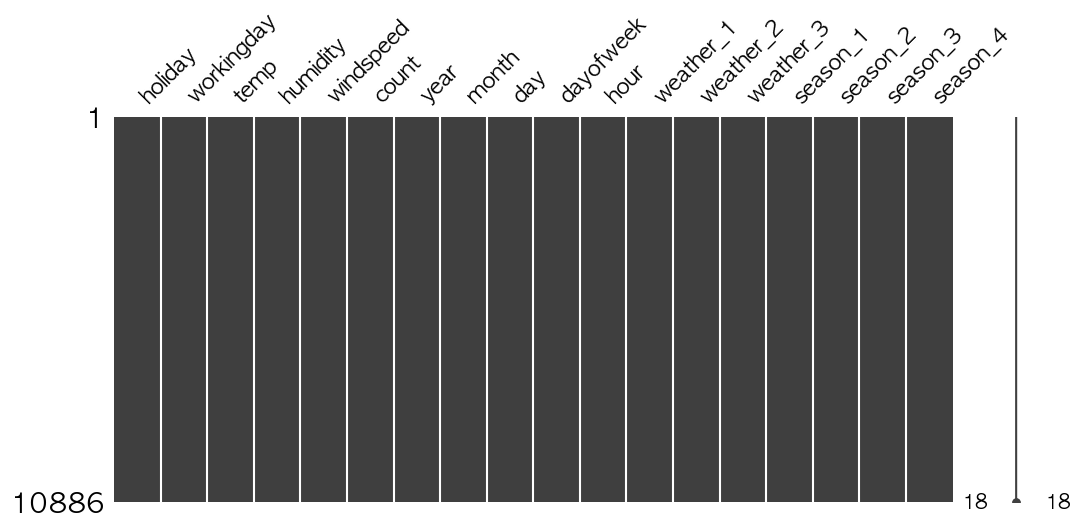

In [80]:
msno.matrix(train_df,figsize=(12,5))

###  피쳐 엔지니어링과 시각화

In [10]:
## datetime 세분화 연, 월, 일, 시간 (분, 초 제외 => 빌림에 있어서 분과 초는 제외)
train_df['datetime'] = pd.to_datetime(train_df['datetime'])
train_df['year'] = train_df['datetime'].dt.year
train_df['month'] = train_df['datetime'].dt.month
train_df['day'] = train_df['datetime'].dt.day
train_df['dayofweek'] = train_df['datetime'].dt.dayofweek
train_df['hour'] = train_df['datetime'].dt.hour
train_df

,datetime,season,holiday,workingday,weather,temp,atemp,humidity,windspeed,casual,registered,count,year,month,day,dayofweek,hour
0,2011-01-01 00:00:00,1,0,0,1,9.84,14.395,81,0.0000,3,13,16,2011,1,1,5,0
1,2011-01-01 01:00:00,1,0,0,1,9.02,13.635,80,0.0000,8,32,40,2011,1,1,5,1
2,2011-01-01 02:00:00,1,0,0,1,9.02,13.635,80,0.0000,5,27,32,2011,1,1,5,2
3,2011-01-01 03:00:00,1,0,0,1,9.84,14.395,75,0.0000,3,10,13,2011,1,1,5,3
4,2011-01-01 04:00:00,1,0,0,1,9.84,14.395,75,0.0000,0,1,1,2011,1,1,5,4
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10881,2012-12-19 19:00:00,4,0,1,1,15.58,19.695,50,26.0027,7,329,336,2012,12,19,2,19
10882,2012-12-19 20:00:00,4,0,1,1,14.76,17.425,57,15.0013,10,231,241,2012,12,19,2,20
10883,2012-12-19 21:00:00,4,0,1,1,13.94,15.910,61,15.0013,4,164,168,2012,12,19,2,21
10884,2012-12-19 22:00:00,4,0,1,1,13.94,17.425,61,6.0032,12,117,129,2012,12,19,2,22


In [11]:
test_df['datetime'] = pd.to_datetime(test_df['datetime'])
test_df['year'] = test_df['datetime'].dt.year
test_df['month'] = test_df['datetime'].dt.month
test_df['day'] = test_df['datetime'].dt.day
test_df['dayofweek'] = test_df['datetime'].dt.dayofweek
test_df['hour'] = test_df['datetime'].dt.hour
test_df

,datetime,season,holiday,workingday,weather,temp,atemp,humidity,windspeed,year,month,day,dayofweek,hour
0,2011-01-20 00:00:00,1,0,1,1,10.66,11.365,56,26.0027,2011,1,20,3,0
1,2011-01-20 01:00:00,1,0,1,1,10.66,13.635,56,0.0000,2011,1,20,3,1
2,2011-01-20 02:00:00,1,0,1,1,10.66,13.635,56,0.0000,2011,1,20,3,2
3,2011-01-20 03:00:00,1,0,1,1,10.66,12.880,56,11.0014,2011,1,20,3,3
4,2011-01-20 04:00:00,1,0,1,1,10.66,12.880,56,11.0014,2011,1,20,3,4
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6488,2012-12-31 19:00:00,1,0,1,2,10.66,12.880,60,11.0014,2012,12,31,0,19
6489,2012-12-31 20:00:00,1,0,1,2,10.66,12.880,60,11.0014,2012,12,31,0,20
6490,2012-12-31 21:00:00,1,0,1,1,10.66,12.880,60,11.0014,2012,12,31,0,21
6491,2012-12-31 22:00:00,1,0,1,1,10.66,13.635,56,8.9981,2012,12,31,0,22


In [12]:
## 본격적인 EDA 전 데이터 제거
# 제거 항목 : casual	registered	
# 이유 : count에 대한 예측으로 회원 count와 비회원 count에 대한 예측은 아니기에 배제

train_df = train_df.drop(columns=["casual", "registered"])

In [13]:
test_df.describe()

,datetime,season,holiday,workingday,weather,temp,atemp,humidity,windspeed,year,month,day,dayofweek,hour
count,6493,6493.000000,6493.000000,6493.000000,6493.000000,6493.000000,6493.000000,6493.000000,6493.000000,6493.000000,6493.000000,6493.000000,6493.000000,6493.000000
mean,2012-01-13 09:27:47.765285632,2.493300,0.029108,0.685815,1.436778,20.620607,24.012865,64.125212,12.631157,2011.503619,6.565070,25.224550,3.007239,11.555367
min,2011-01-20 00:00:00,1.000000,0.000000,0.000000,1.000000,0.820000,0.000000,16.000000,0.000000,2011.000000,1.000000,20.000000,0.000000,0.000000
25%,2011-07-22 15:00:00,2.000000,0.000000,0.000000,1.000000,13.940000,16.665000,49.000000,7.001500,2011.000000,4.000000,22.000000,1.000000,6.000000
50%,2012-01-20 23:00:00,3.000000,0.000000,1.000000,1.000000,21.320000,25.000000,65.000000,11.001400,2012.000000,7.000000,25.000000,3.000000,12.000000
75%,2012-07-20 17:00:00,3.000000,0.000000,1.000000,2.000000,27.060000,31.060000,81.000000,16.997900,2012.000000,10.000000,28.000000,5.000000,18.000000
max,2012-12-31 23:00:00,4.000000,1.000000,1.000000,4.000000,40.180000,50.000000,100.000000,55.998600,2012.000000,12.000000,31.000000,6.000000,23.000000
std,NaN,1.091258,0.168123,0.464226,0.648390,8.059583,8.782741,19.293391,8.250151,0.500025,3.429462,3.339411,1.997714,6.912526


## EDA
### 상관관계

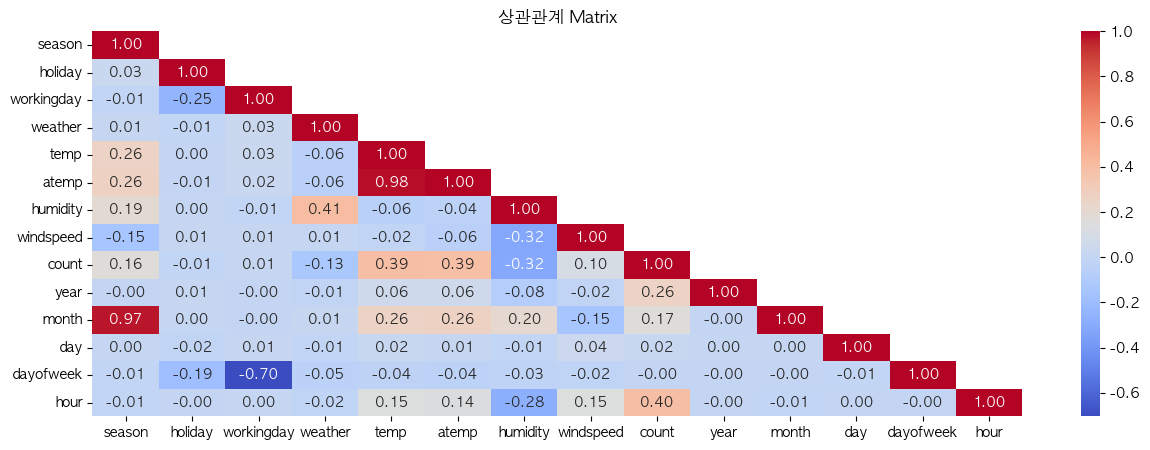

In [14]:
corrMatt = train_df.drop(columns=['datetime']).corr()
mask = np.array(corrMatt)
mask[np.tril_indices_from(mask)] = False

plt.figure(figsize=(15,5))

sns.heatmap(
    train_df.drop(columns=['datetime']).corr(),
    mask=mask,
    annot=True,
    cmap='coolwarm',
    fmt='.2f'
)
plt.title('상관관계 Matrix')
plt.show()


In [15]:
train_df.drop(columns=['datetime']).corr()

,season,holiday,workingday,weather,temp,atemp,humidity,windspeed,count,year,month,day,dayofweek,hour
season,1.000000,0.029368,-0.008126,0.008879,0.258689,0.264744,0.190610,-0.147121,0.163439,-0.004797,0.971524,0.001729,-0.010553,-0.006546
holiday,0.029368,1.000000,-0.250491,-0.007074,0.000295,-0.005215,0.001929,0.008409,-0.005393,0.012021,0.001731,-0.015877,-0.191832,-0.000354
workingday,-0.008126,-0.250491,1.000000,0.033772,0.029966,0.024660,-0.010880,0.013373,0.011594,-0.002482,-0.003394,0.009829,-0.704267,0.002780
weather,0.008879,-0.007074,0.033772,1.000000,-0.055035,-0.055376,0.406244,0.007261,-0.128655,-0.012548,0.012144,-0.007890,-0.047692,-0.022740
temp,0.258689,0.000295,0.029966,-0.055035,1.000000,0.984948,-0.064949,-0.017852,0.394454,0.061226,0.257589,0.015551,-0.038466,0.145430
atemp,0.264744,-0.005215,0.024660,-0.055376,0.984948,1.000000,-0.043536,-0.057473,0.389784,0.058540,0.264173,0.011866,-0.040235,0.140343
humidity,0.190610,0.001929,-0.010880,0.406244,-0.064949,-0.043536,1.000000,-0.318607,-0.317371,-0.078606,0.204537,-0.011335,-0.026507,-0.278011
windspeed,-0.147121,0.008409,0.013373,0.007261,-0.017852,-0.057473,-0.318607,1.000000,0.101369,-0.015221,-0.150192,0.036157,-0.024804,0.146631
count,0.163439,-0.005393,0.011594,-0.128655,0.394454,0.389784,-0.317371,0.101369,1.000000,0.260403,0.166862,0.019826,-0.002283,0.400601
year,-0.004797,0.012021,-0.002482,-0.012548,0.061226,0.058540,-0.078606,-0.015221,0.260403,1.000000,-0.004932,0.001800,-0.003785,-0.004234


In [16]:
corr_pairs = (
    train_df.drop(columns=['datetime']).corr()
    .abs()                               # 절댓값 기준
    .unstack()                           # (변수1, 변수2) 형태
    .reset_index()
)

corr_pairs = corr_pairs[corr_pairs['level_0'] != corr_pairs['level_1']]
corr_pairs.sort_values(by=0, ascending=False).head(20)

## temp ≒  atemp 데이터는 제거할 예정

,level_0,level_1,0
61,temp,atemp,0.984948
74,atemp,temp,0.984948
10,season,month,0.971524
140,month,season,0.971524
40,workingday,dayofweek,0.704267
170,dayofweek,workingday,0.704267
48,weather,humidity,0.406244
87,humidity,weather,0.406244
190,hour,count,0.400601
125,count,hour,0.400601


In [17]:
train_df = train_df.drop(columns=["atemp"])
test_df = test_df.drop(columns=["atemp"])

In [18]:
train_df.columns

Index(['datetime', 'season', 'holiday', 'workingday', 'weather', 'temp',
       'humidity', 'windspeed', 'count', 'year', 'month', 'day', 'dayofweek',
       'hour'],
      dtype='object')

## count 정규분포 확인

plt.figure

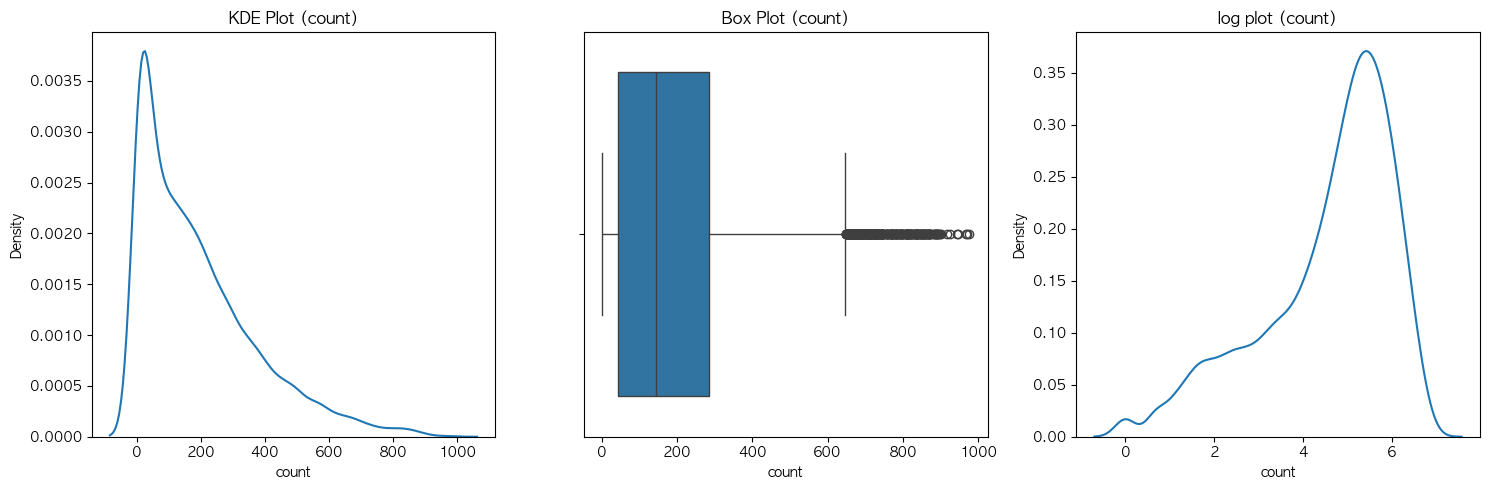

In [19]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# 왼쪽: KDE plot
sns.kdeplot(data=train_df, x="count", ax=axes[0])
axes[0].set_title("KDE Plot (count)")

# 가운데: Box plot
sns.boxplot(data=train_df, x="count", ax=axes[1])
axes[1].set_title("Box Plot (count)")

# 중간 : log KDE plot
sns.kdeplot(np.log(train_df["count"]), ax=axes[2]);
axes[2].set_title("log plot (count)")

plt.tight_layout()
plt.show()

## 왼쪽편중

## 타겟 변수이기 때문에 정규화 및 이상치 제거를 하지 않음 다만 count의 최솟값은 1인걸 기억하자
## 추후 모델 학습 할 때에는 로그 변환도 이용해보자

## count와 관련한 그래프 

['datetime', 'holiday', 'workingday', 'weather', 'temp', 'humidity', 'windspeed', 'count', 'year', 'month', 'day', 'hour', 'dayofweek']

In [20]:
train_df.columns

Index(['datetime', 'season', 'holiday', 'workingday', 'weather', 'temp',
       'humidity', 'windspeed', 'count', 'year', 'month', 'day', 'dayofweek',
       'hour'],
      dtype='object')

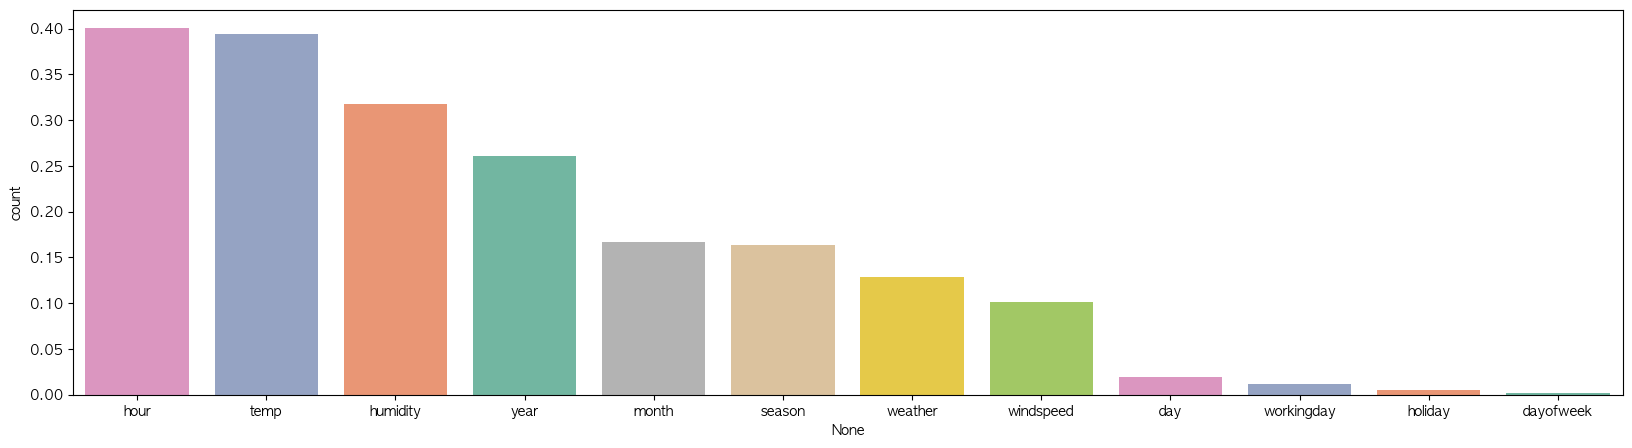

In [21]:
count_corr_df = pd.DataFrame(train_df.drop(columns=['datetime']).corr().abs()["count"].drop("count").sort_values(ascending=False))

plt.figure(figsize=(20,5))

sns.barplot(data=count_corr_df, x=count_corr_df.index, y="count", palette="Set2", hue='count', legend=False)

plt.show()

In [22]:
train_df = train_df.drop(columns=["datetime"])
test_df = test_df.drop(columns=["datetime"])

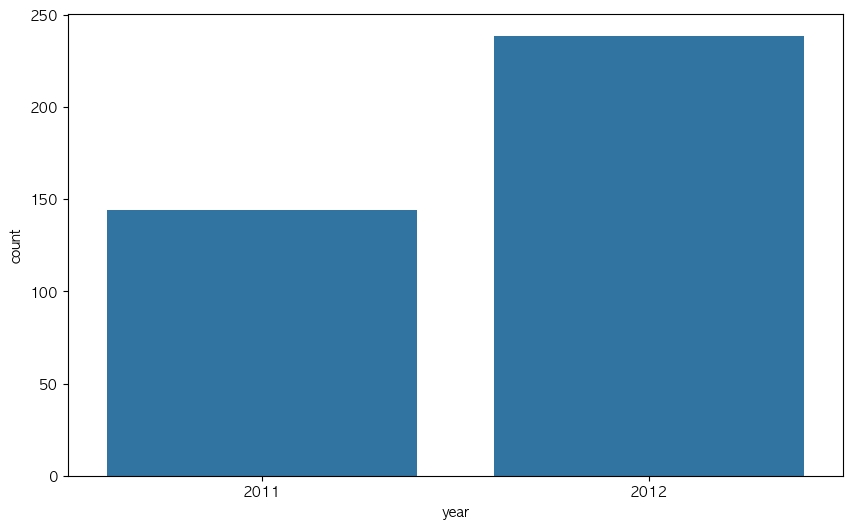

In [23]:
# 연도별 대여 수
plt.figure(figsize=(10, 6))
sns.barplot(data=train_df, x='year', y='count', errorbar=None)
plt.show()

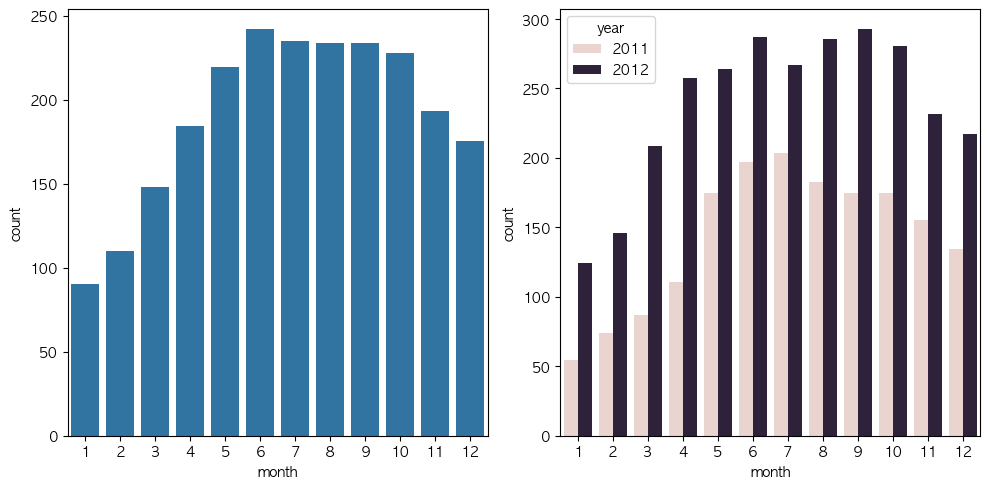

In [24]:
# 월별 ~ 연도 월별 < 여름 ~ 가을기간 집중 >
fig, axes = plt.subplots(1, 2, figsize=(10, 5))

sns.barplot(data=train_df, x="month", y="count", ax=axes[0], errorbar=None)

sns.barplot(data=train_df, x="month", y="count", hue="year", ax=axes[1], errorbar=None)

plt.tight_layout()
plt.show()


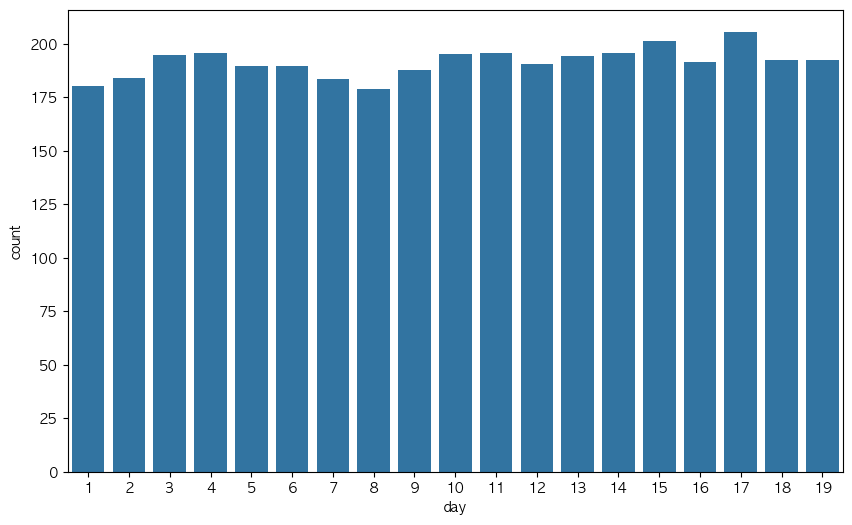

In [25]:
# 일자별 대여 수
plt.figure(figsize=(10, 6))
sns.barplot(data=train_df, x='day', y='count', errorbar=None)
plt.show()

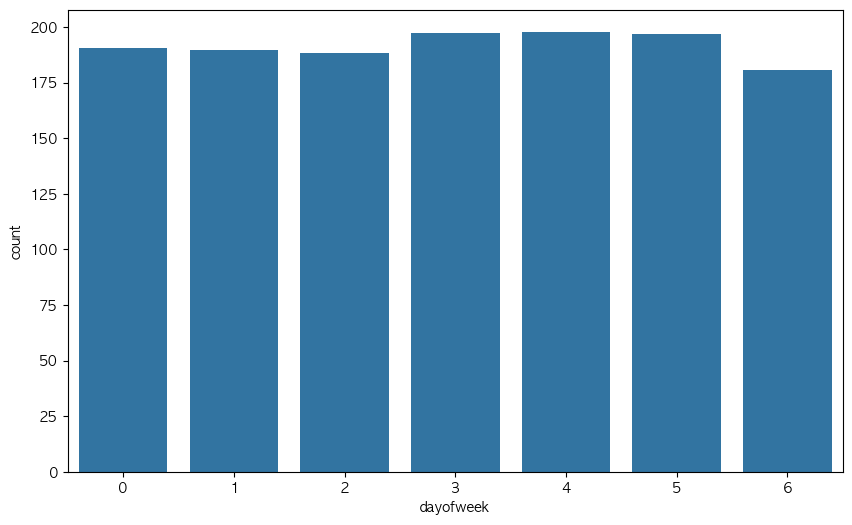

In [26]:
# 요일별 대여 수
plt.figure(figsize=(10, 6))
sns.barplot(data=train_df, x='dayofweek', y='count', errorbar=None)
plt.show()

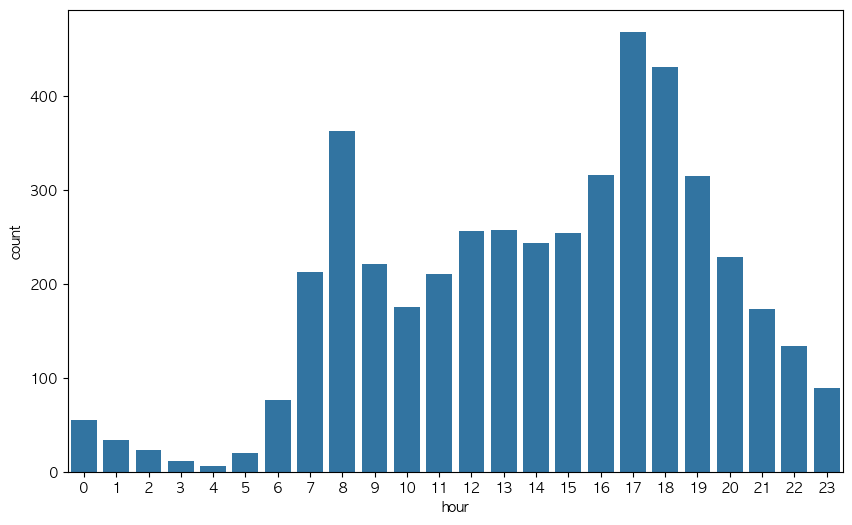

In [27]:
# 시간대별 대여 수
plt.figure(figsize=(10, 6))
sns.barplot(data=train_df, x='hour', y='count', errorbar=None)
plt.show()

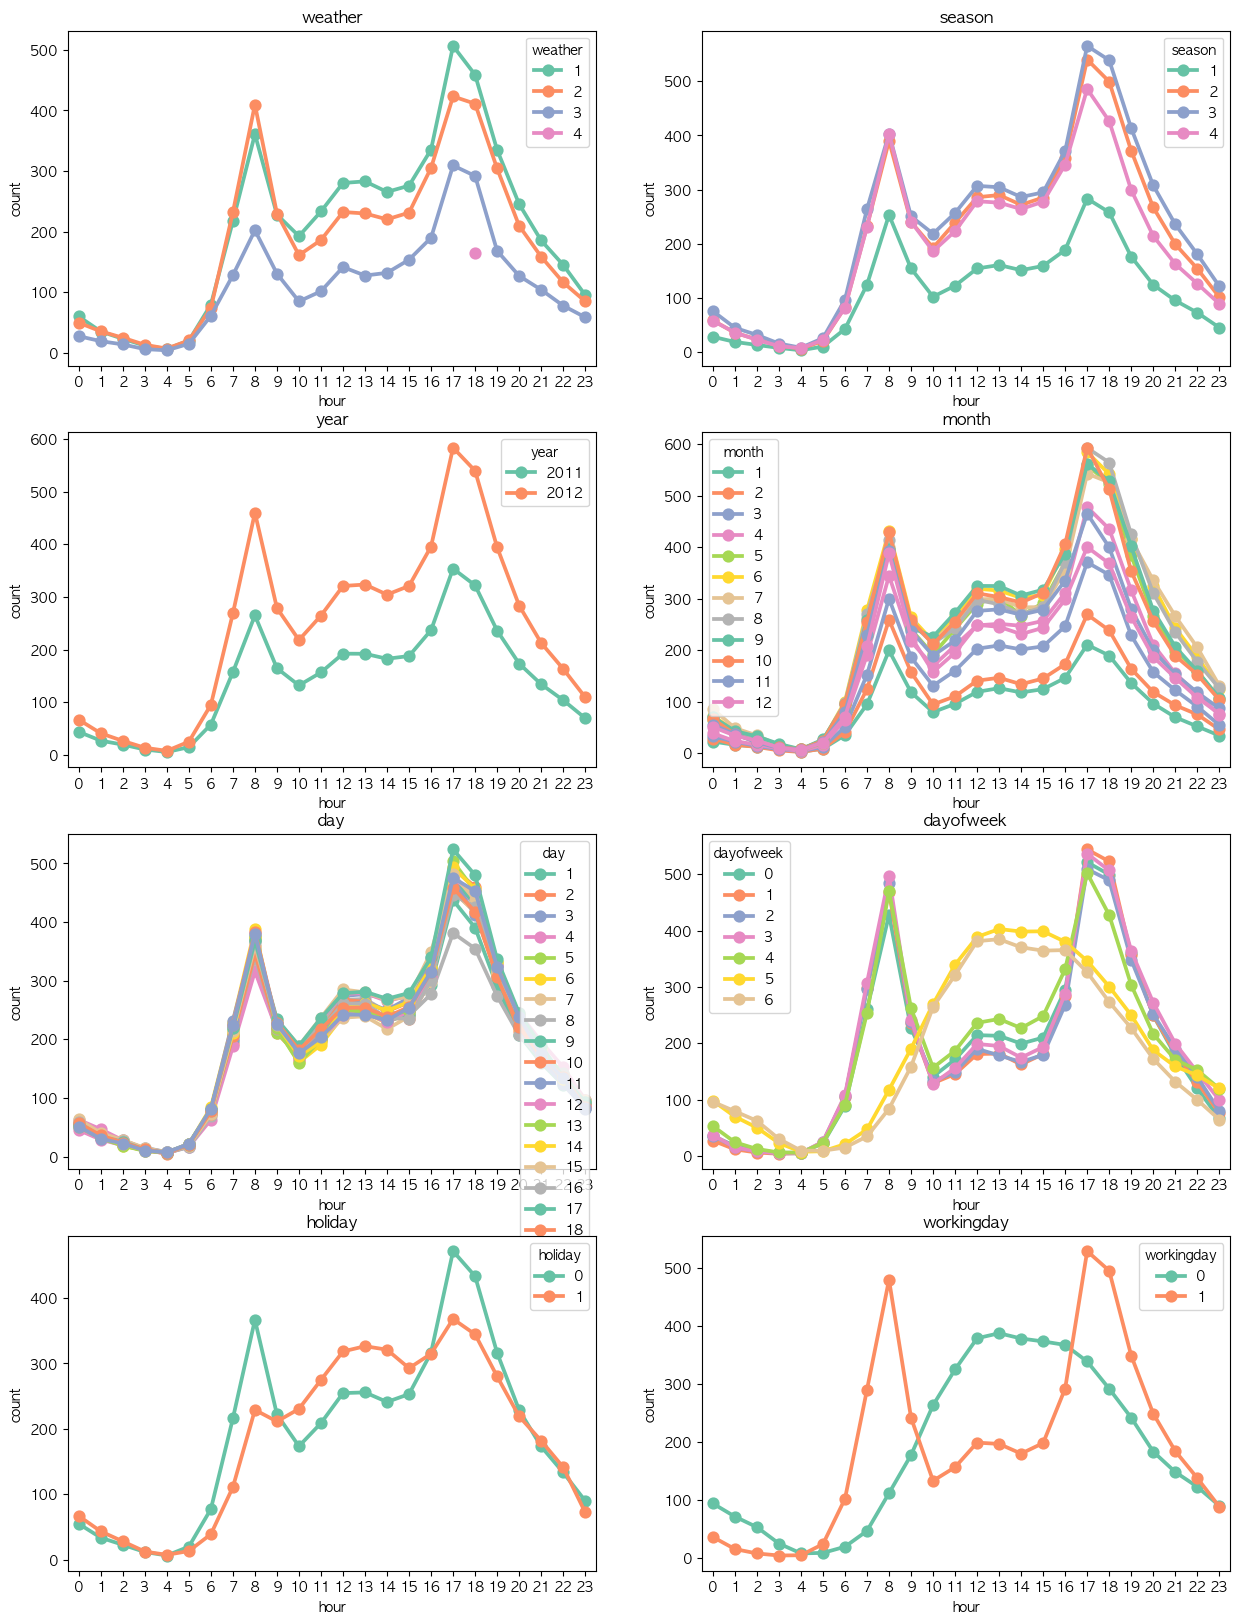

In [28]:
fig, axes = plt.subplots(4, 2, figsize=(15,20))  
axes = axes.flatten()
hues = ["weather", "season", "year", "month", "day", "dayofweek", "holiday", "workingday"]

# 시간대별 평균 대여 수량 포인트플롯

for ax, hue in zip(axes, hues):
    sns.pointplot(data=train_df, x='hour', y='count', hue=hue, palette="Set2", errorbar=None, ax=ax)
    ax.set_xlabel("hour")
    ax.set_title(hue)

# plt.tight_layout()
plt.show()



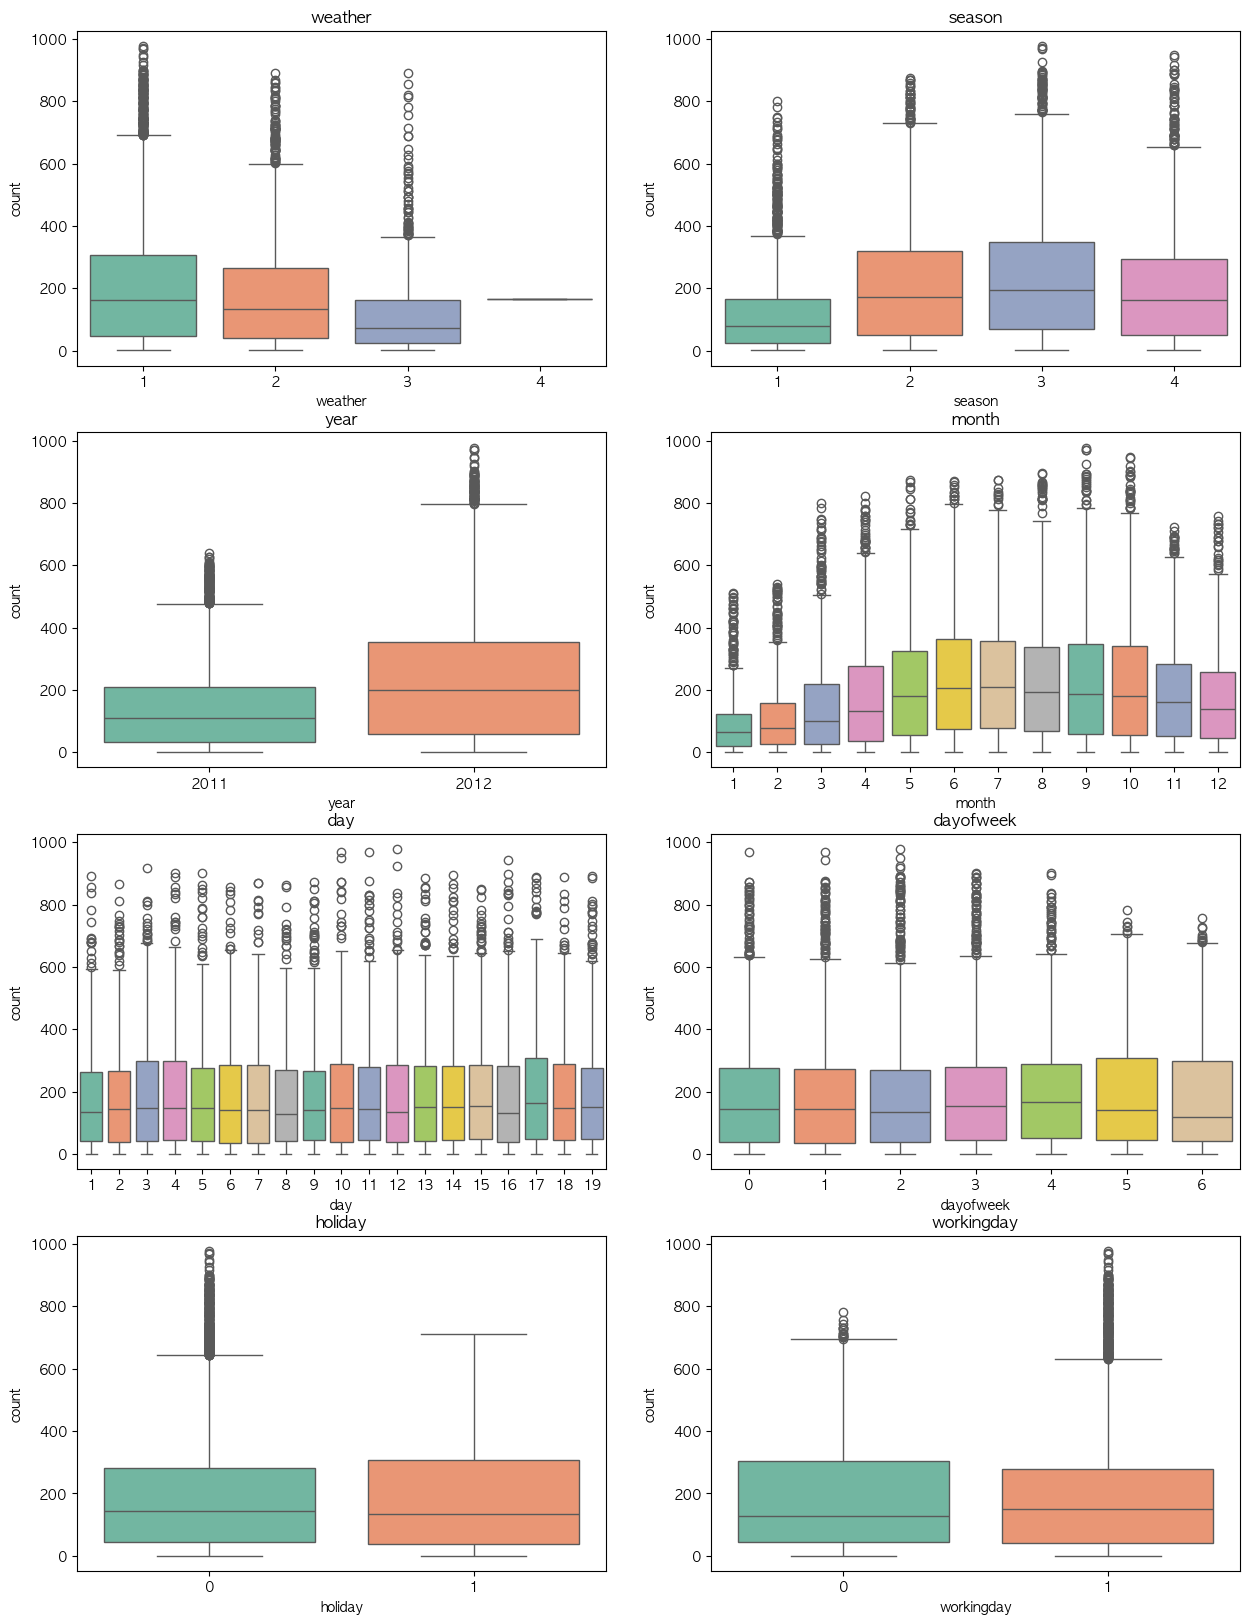

In [29]:
fig, axes = plt.subplots(4, 2, figsize=(15,20))  
axes = axes.flatten()
features = ["weather", "season", "year", "month", "day", "dayofweek", "holiday", "workingday"]

# 계절, 날씨, 월, 일, 공휴일, 근무일별 대여 수량 박스플롯

for ax, feature in zip(axes, features):
    sns.boxplot(
        data=train_df,
        x=feature,
        y='count',
        ax=ax,
        palette="Set2",
        legend=False,
        hue=feature
    )
    ax.set_title(feature)

# plt.tight_layout()
plt.show()



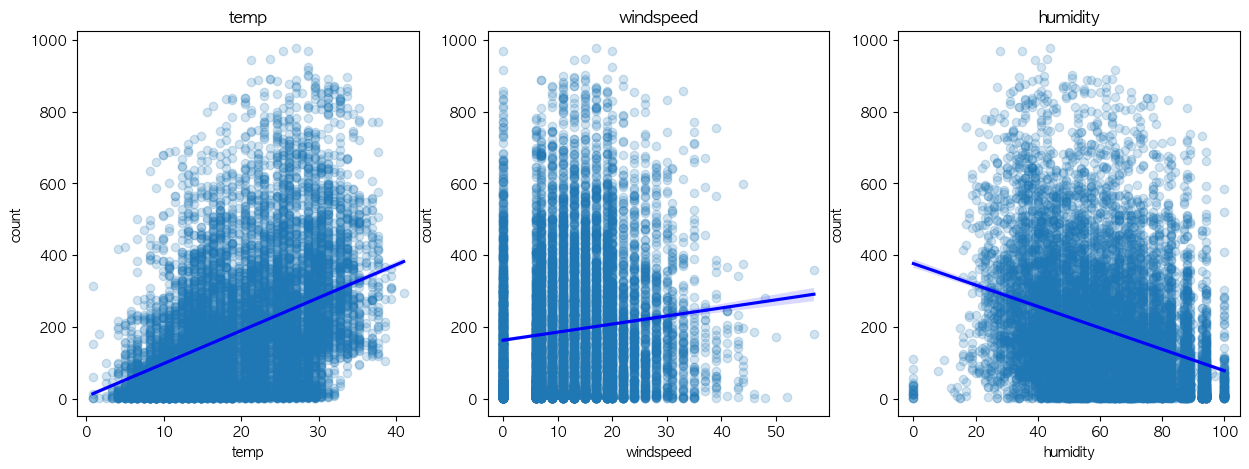

In [30]:
fig, axes = plt.subplots(1, 3, figsize=(15,5))  
features = ["temp", "windspeed", "humidity"]

for ax, feature in zip(axes, features):
    sns.regplot(
        data=train_df,
        x=feature,
        y='count',
        ax=ax,
        scatter_kws={"alpha" : 0.2},
        line_kws={'color': 'blue'}
    )
    ax.set_title(feature)

plt.show()

피쳐 엔지니어링 (weather , season)

In [31]:
train_df = pd.get_dummies(train_df, columns=["weather", "season"], dtype=int)

train_df

,holiday,workingday,temp,humidity,windspeed,count,year,month,day,dayofweek,hour,weather_1,weather_2,weather_3,weather_4,season_1,season_2,season_3,season_4
0,0,0,9.84,81,0.0000,16,2011,1,1,5,0,1,0,0,0,1,0,0,0
1,0,0,9.02,80,0.0000,40,2011,1,1,5,1,1,0,0,0,1,0,0,0
2,0,0,9.02,80,0.0000,32,2011,1,1,5,2,1,0,0,0,1,0,0,0
3,0,0,9.84,75,0.0000,13,2011,1,1,5,3,1,0,0,0,1,0,0,0
4,0,0,9.84,75,0.0000,1,2011,1,1,5,4,1,0,0,0,1,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10881,0,1,15.58,50,26.0027,336,2012,12,19,2,19,1,0,0,0,0,0,0,1
10882,0,1,14.76,57,15.0013,241,2012,12,19,2,20,1,0,0,0,0,0,0,1
10883,0,1,13.94,61,15.0013,168,2012,12,19,2,21,1,0,0,0,0,0,0,1
10884,0,1,13.94,61,6.0032,129,2012,12,19,2,22,1,0,0,0,0,0,0,1


In [32]:
train_df["weather_4"].value_counts()

weather_4
0    10885
1        1
Name: count, dtype: int64

In [33]:
test_df = pd.get_dummies(test_df, columns=["weather", "season"], dtype=int)
test_df

,holiday,workingday,temp,humidity,windspeed,year,month,day,dayofweek,hour,weather_1,weather_2,weather_3,weather_4,season_1,season_2,season_3,season_4
0,0,1,10.66,56,26.0027,2011,1,20,3,0,1,0,0,0,1,0,0,0
1,0,1,10.66,56,0.0000,2011,1,20,3,1,1,0,0,0,1,0,0,0
2,0,1,10.66,56,0.0000,2011,1,20,3,2,1,0,0,0,1,0,0,0
3,0,1,10.66,56,11.0014,2011,1,20,3,3,1,0,0,0,1,0,0,0
4,0,1,10.66,56,11.0014,2011,1,20,3,4,1,0,0,0,1,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6488,0,1,10.66,60,11.0014,2012,12,31,0,19,0,1,0,0,1,0,0,0
6489,0,1,10.66,60,11.0014,2012,12,31,0,20,0,1,0,0,1,0,0,0
6490,0,1,10.66,60,11.0014,2012,12,31,0,21,1,0,0,0,1,0,0,0
6491,0,1,10.66,56,8.9981,2012,12,31,0,22,1,0,0,0,1,0,0,0


In [34]:
train_df.drop(columns=["weather_4"], inplace=True)
test_df.drop(columns=["weather_4"], inplace=True)

## 예측 모델링 (회귀 모델)

In [35]:
## 모델링 라이브러리
from sklearn.model_selection import train_test_split
from sklearn.metrics import root_mean_squared_log_error, mean_squared_log_error, mean_squared_error, root_mean_squared_error
from sklearn.linear_model import LinearRegression

In [36]:
X_train, X_val, y_train, y_val = train_test_split(
    train_df.drop(['count' ],axis=1),
    train_df['count'],
    test_size=0.20, 
    random_state=42
)



In [37]:
linear_reg_model = LinearRegression()

In [38]:
linear_reg_model.fit(X_train, y_train) # 모델 훈련

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [39]:
y_val_predict = linear_reg_model.predict(X_val)

In [40]:
y_val_predict[y_val_predict < 0]
y_val_predict = np.maximum(0, y_val_predict)

In [41]:
rmsle = root_mean_squared_log_error(y_val, y_val_predict)

In [42]:
rmsle

1.3081833883570064

### 정규화 규제
다변량 선형회귀에서는 여러 독립변수가 동시에 사용되면서 변수 간 상관관계, 즉 다중공선성이 발생하기 쉽고, 이로 인해 회귀계수가 과도하게 커지거나 데이터의 작은 변화에도 계수가 크게 변하는 불안정한 모델이 만들어질 수 있다. 또한 일반적인 선형회귀는 오차만 최소화하기 때문에 불필요한 변수까지 모두 학습하여 과적합이 발생할 가능성이 높고, 모델의 일반화 성능과 해석력이 떨어진다. Lasso와 Ridge 회귀는 이러한 문제를 해결하기 위해 손실함수에 계수 크기에 대한 페널티를 추가한 정규화 기법으로, Ridge는 모든 변수를 유지하되 계수의 크기를 제한하여 다중공선성으로 인한 계수 폭주를 완화하고 예측을 안정화하는 데 목적이 있으며, Lasso는 중요하지 않은 변수의 계수를 0으로 만들어 자동으로 변수 선택을 수행함으로써 모델을 단순화하고 해석력을 높인다. 따라서 Lasso와 Ridge 회귀는 다변량 데이터 환경에서 과적합을 줄이고, 계수의 안정성과 일반화 성능을 향상시키기 위해 사용된다.

** 다중 공산성 : 회귀 분석에서 여러 독립변수들(설명변수)이 서로 높은 상관관계를 가져 독립성 가정을 위배하는 현상

In [43]:
from sklearn.linear_model import ElasticNet, Lasso, Ridge
from sklearn.model_selection import GridSearchCV ## 하이퍼 파라미터 튜닝
from sklearn import metrics

Ridge

In [44]:
ridge_model = Ridge()

In [45]:
ridge_model

,"alpha alpha: {float, ndarray of shape (n_targets,)}, default=1.0Constant that multiplies the L2 term, controlling regularizationstrength. `alpha` must be a non-negative float i.e. in `[0, inf)`.When `alpha = 0`, the objective is equivalent to ordinary leastsquares, solved by the :class:`LinearRegression` object. For numericalreasons, using `alpha = 0` with the `Ridge` object is not advised.Instead, you should use the :class:`LinearRegression` object.If an array is passed, penalties are assumed to be specific to thetargets. Hence they must correspond in number.",1.0
,"fit_intercept fit_intercept: bool, default=TrueWhether to fit the intercept for this model. If setto false, no intercept will be used in calculations(i.e. ``X`` and ``y`` are expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"max_iter max_iter: int, default=NoneMaximum number of iterations for conjugate gradient solver.For 'sparse_cg' and 'lsqr' solvers, the default value is determinedby scipy.sparse.linalg. For 'sag' solver, the default value is 1000.For 'lbfgs' solver, the default value is 15000.",None
,"tol tol: float, default=1e-4The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for each solver:- 'svd': `tol` has no impact.- 'cholesky': `tol` has no impact.- 'sparse_cg': norm of residuals smaller than `tol`.- 'lsqr': `tol` is set as atol and btol of scipy.sparse.linalg.lsqr, which control the norm of the residual vector in terms of the norms of matrix and coefficients.- 'sag' and 'saga': relative change of coef smaller than `tol`.- 'lbfgs': maximum of the absolute (projected) gradient=max|residuals| smaller than `tol`... versionchanged:: 1.2 Default value changed from 1e-3 to 1e-4 for consistency with other linear models.",0.0001
,"solver solver: {'auto', 'svd', 'cholesky', 'lsqr', 'sparse_cg', 'sag', 'saga', 'lbfgs'}, default='auto'Solver to use in the computational routines:- 'auto' chooses the solver automatically based on the type of data.- 'svd' uses a Singular Value Decomposition of X to compute the Ridge coefficients. It is the most stable solver, in particular more stable for singular matrices than 'cholesky' at the cost of being slower.- 'cholesky' uses the standard :func:`scipy.linalg.solve` function to obtain a closed-form solution.- 'sparse_cg' uses the conjugate gradient solver as found in :func:`scipy.sparse.linalg.cg`. As an iterative algorithm, this solver is more appropriate than 'cholesky' for large-scale data (possibility to set `tol` and `max_iter`).- 'lsqr' uses the dedicated regularized least-squares routine :func:`scipy.sparse.linalg.lsqr`. It is the fastest and uses an iterative procedure.- 'sag' uses a Stochastic Average Gradient descent, and 'saga' uses its improved, unbiased version named SAGA. Both methods also use an iterative procedure, and are often faster than other solvers when both n_samples and n_features are large. Note that 'sag' and 'saga' fast convergence is only guaranteed on features with approximately the same scale. You can preprocess the data with a scaler from :mod:`sklearn.preprocessing`.- 'lbfgs' uses L-BFGS-B algorithm implemented in :func:`scipy.optimize.minimize`. It can be used only when `positive` is True.All solvers except 'svd' support both dense and sparse data. However, only'lsqr', 'sag', 'sparse_cg', and 'lbfgs' support sparse input when`fit_intercept` is True... versionadded:: 0.17 Stochastic Average Gradient descent solver... versionadded:: 0.19 SAGA solver.",'auto'
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive.Only 'lbfgs' solver is supported in this case.",False
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag' or 'saga' to shuffle the data.See :term:`Glossary ` for details... versionadded:: 0.17 `random_state` to support Stochastic Average Gradient.",None


In [46]:
# 하이퍼 파라미터 값 목록
ridge_params = {'max_iter':[3000], 'alpha':[0.1, 1, 2, 3, 4, 10, 30, 100, 200, 300, 400, 800, 900, 1000]}

In [47]:
# 1. 타깃값 로그 변환 (log1p 사용으로 0값 에러 방지)
log_y_train = np.log1p(y_train)
log_y_val = np.log1p(y_val)

# 2. 그리드 서치 및 학습
gridsearch_ridge_model = GridSearchCV(
    ridge_model,
    ridge_params,
    scoring='neg_mean_squared_error', # 로그 변환된 타깃이므로 MSE를 기준으로 최적화
    cv=5
)

gridsearch_ridge_model.fit(X_train, log_y_train)

print('최적 하이퍼파라미터 :', gridsearch_ridge_model.best_params_)

# 3. 예측 (검증 데이터 X_val 사용)
preds = gridsearch_ridge_model.best_estimator_.predict(X_val)

# 4. 평가 (이미 로그 상태이므로 RMSE를 구하면 그것이 곧 RMSLE)
rmsle = root_mean_squared_error(log_y_val, preds)

print(f'릿지 회귀 검증 데이터 RMSLE 값 : {rmsle:.4f}')

최적 하이퍼파라미터 : {'alpha': 30, 'max_iter': 3000}
릿지 회귀 검증 데이터 RMSLE 값 : 1.0160


In [48]:
lasso_model = Lasso()
# 하이퍼파라미터 값 목록
lasso_alpha = 1/np.array([0.1, 1, 2, 3, 4, 10, 30, 100, 200, 300, 400, 800, 900, 1000])
lasso_params = {'max_iter':[3000], 'alpha':lasso_alpha}

In [49]:
# 그리드서치(with 라쏘) 및 학습
gridsearch_lasso_model = GridSearchCV(
    lasso_model,
    lasso_params,
    scoring='neg_mean_squared_error',
    cv=5
)

gridsearch_lasso_model.fit(X_train, log_y_train)

print('최적 하이퍼파라미터 :', gridsearch_lasso_model.best_params_)

# 3. 예측 (검증 데이터 X_val 사용)
preds = gridsearch_lasso_model.best_estimator_.predict(X_val)

# 4. 평가 (이미 로그 상태이므로 RMSE를 구하면 그것이 곧 RMSLE)
rmsle = root_mean_squared_error(log_y_val, preds)

print(f'라쏘 회귀 검증 데이터 RMSLE 값 : {rmsle:.4f}')

최적 하이퍼파라미터 : {'alpha': np.float64(0.0025), 'max_iter': 3000}
라쏘 회귀 검증 데이터 RMSLE 값 : 1.0160


In [50]:
# 1. 모델 객체 생성
elastic_model = ElasticNet()

# 2. 하이퍼파라미터 설정
# alpha: 규제의 강도
# l1_ratio: L1 규제의 비율 (0이면 릿지에 가깝고, 1이면 라쏘와 동일합니다)
elastic_alpha = 1/np.array([0.1, 1, 2, 3, 4, 10, 30, 100, 200, 300, 400, 800, 900, 1000])
elastic_l1_ratio = [0.1, 0.3, 0.5, 0.7, 0.9] # 일반적인 탐색 범위

elastic_params = {
    'max_iter': [3000], 
    'alpha': elastic_alpha,
    'l1_ratio': elastic_l1_ratio
}

# 3. 그리드서치 및 학습
gridsearch_elastic_model = GridSearchCV(
    elastic_model,
    elastic_params,
    scoring='neg_mean_squared_error',
    cv=5
)

gridsearch_elastic_model.fit(X_train, log_y_train)

print('최적 하이퍼파라미터 :', gridsearch_elastic_model.best_params_)

# 4. 예측 (검증 데이터 X_val 사용)
preds = gridsearch_elastic_model.best_estimator_.predict(X_val)

# 5. 평가
rmsle = root_mean_squared_error(log_y_val, preds)
print(f'엘라스틱넷 회귀 검증 데이터 RMSLE 값 : {rmsle:.4f}')

최적 하이퍼파라미터 : {'alpha': np.float64(0.0025), 'l1_ratio': 0.9, 'max_iter': 3000}
엘라스틱넷 회귀 검증 데이터 RMSLE 값 : 1.0160


In [71]:
# 계수(Coefficient) 추출
coefficients = gridsearch_elastic_model.best_estimator_.coef_
feature_names = X_train.columns

# 데이터프레임 변환
coeff_df = pd.DataFrame({'feature': feature_names, 'coefficient': coefficients})
coeff_df = coeff_df.sort_values(by='coefficient', ascending=False)

coeff_df

,feature,coefficient
5,year,0.412724
11,weather_2,0.124871
9,hour,0.097614
6,month,0.063281
2,temp,0.055162
8,dayofweek,0.023935
7,day,0.002435
4,windspeed,0.002209
14,season_2,0.000000
13,season_1,0.000000


규제 전 선형 회귀 모델은 RMSLE 1.308로 높은 오차를 보였으나, Ridge, Lasso, ElasticNet과 같은 정규화 기법을 적용한 이후 RMSLE가 약 1.016 수준으로 개선되었습니다.
<br>
이는 다중공선성으로 인한 과적합이 주요 원인이었음을 의미하며, **규제 방식의 차이보다는 규제의 적용 자체**가 성능 개선에 핵심적이었음을 확인했습니다.

In [51]:
from sklearn.ensemble import RandomForestRegressor

# 1. 모델 객체 생성
randomforest_model = RandomForestRegressor()
# 2. 그리드서치 및 학습
rf_params = {'random_state':[42], 'n_estimators':[100, 120, 140]}
gridsearch_random_forest_model = GridSearchCV(
    randomforest_model,
    rf_params,
    scoring='neg_mean_squared_error',
    cv=5
)

gridsearch_random_forest_model.fit(X_train, log_y_train)

print('최적 하이퍼파라미터 :', gridsearch_random_forest_model.best_params_)

최적 하이퍼파라미터 : {'n_estimators': 140, 'random_state': 42}


In [52]:
preds = gridsearch_random_forest_model.best_estimator_.predict(X_val)
rmsle = root_mean_squared_error(log_y_val, preds)
print(f'랜덤포레스트 회귀 검증 데이터 RMSLE 값 : {rmsle:.4f}')

랜덤포레스트 회귀 검증 데이터 RMSLE 값 : 0.3021


In [53]:
from sklearn.ensemble import GradientBoostingRegressor

gradientBoost_model = GradientBoostingRegressor()
gb_params = {'n_estimators': [4000], 'alpha': [0.01] }

gridsearch_gradientBoost_model = GridSearchCV(
    gradientBoost_model,
    gb_params,
    scoring='neg_mean_squared_error',
    cv=5
)

gridsearch_gradientBoost_model.fit(X_train, log_y_train)

print('최적 하이퍼파라미터 :', gridsearch_gradientBoost_model.best_params_)

preds = gridsearch_gradientBoost_model.best_estimator_.predict(X_val)
rmsle = root_mean_squared_error(log_y_val, preds)

print(f'그래디언 부스트 모델 회귀 검증 데이터 RMSLE 값 : {rmsle:.4f}')

최적 하이퍼파라미터 : {'alpha': 0.01, 'n_estimators': 4000}
그래디언 부스트 모델 회귀 검증 데이터 RMSLE 값 : 0.2905


In [55]:
from xgboost import XGBRegressor
from sklearn.model_selection import RandomizedSearchCV

XGB_model = XGBRegressor()


xgb_params = {
    'n_estimators': [500, 1000, 2000],
    'learning_rate': [0.01, 0.05],
    'max_depth': [3, 5, 7],
    'subsample': [0.8, 1.0],
    'colsample_bytree': [0.8, 1.0],
    'gamma': [0, 1],
    'reg_alpha': [0, 0.1],
    'reg_lambda': [1, 5]
}


# n_iter=30 이면 576개 중 30개만 랜덤하게 골라서 수행합니다.
gridsearch_XGB_model = RandomizedSearchCV(
    XGB_model,
    xgb_params,
    n_iter=30, 
    scoring='neg_mean_squared_error',
    cv=5,
    n_jobs=-1, # 모든 CPU 코어 사용
    random_state=42
)
gridsearch_XGB_model.fit(X_train, log_y_train)

print('최적 하이퍼파라미터 :', gridsearch_XGB_model.best_params_)

preds = gridsearch_XGB_model.best_estimator_.predict(X_val)
rmsle = root_mean_squared_error(log_y_val, preds)

print(f'XGB 부스트 모델 회귀 검증 데이터 RMSLE 값 : {rmsle:.4f}')



최적 하이퍼파라미터 : {'subsample': 0.8, 'reg_lambda': 1, 'reg_alpha': 0.1, 'n_estimators': 2000, 'max_depth': 7, 'learning_rate': 0.01, 'gamma': 0, 'colsample_bytree': 1.0}
XGB 부스트 모델 회귀 검증 데이터 RMSLE 값 : 0.2714


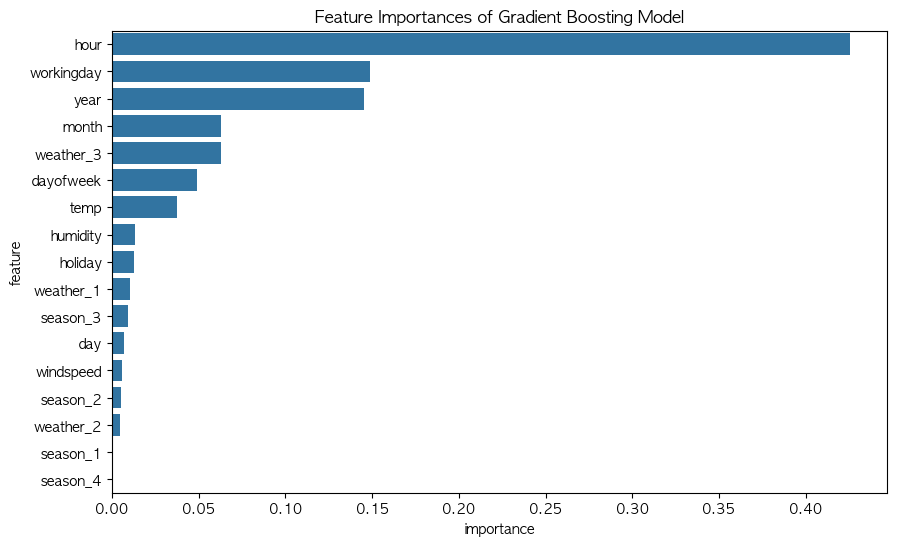

In [68]:
best_model = gridsearch_XGB_model.best_estimator_

# 2. 특성 중요도 추출
importances = best_model.feature_importances_
feature_names = X_train.columns

# 3. 데이터프레임으로 변환 및 정렬
feature_importances = pd.DataFrame({'feature': feature_names, 'importance': importances})
feature_importances = feature_importances.sort_values(by='importance', ascending=False)

# 4. 시각화
plt.figure(figsize=(10, 6))
sns.barplot(x='importance', y='feature', data=feature_importances)
plt.title('Feature Importances of Gradient Boosting Model')
plt.show()

In [72]:
final_test = gridsearch_XGB_model.best_estimator_.predict(test_df)

In [74]:
real_count = np.expm1(final_test)

# 2. 데이터프레임에 새로운 컬럼 'count' 추가
test_df['count'] = real_count


       count
0  13.343148
1   4.731359
2   3.703279
3   2.295966
4   1.713589


In [78]:
test_df.sort_values(by="count")

,holiday,workingday,temp,humidity,windspeed,year,month,day,dayofweek,hour,weather_1,weather_2,weather_3,season_1,season_2,season_3,season_4,count
52,0,0,0.82,48,19.9995,2011,1,22,5,4,0,1,0,1,0,0,0,1.234967
675,0,1,9.84,32,19.9995,2011,3,29,1,3,1,0,0,0,1,0,0,1.372022
261,0,0,9.02,44,36.9974,2011,2,20,6,4,1,0,0,1,0,0,0,1.414565
237,0,1,8.20,59,15.0013,2011,1,31,0,4,1,0,0,1,0,0,0,1.541321
96,0,1,1.64,45,16.9979,2011,1,24,0,3,1,0,0,1,0,0,0,1.605612
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5781,0,1,27.88,41,0.0000,2012,10,23,1,17,1,0,0,0,0,0,1,881.876221
5541,0,1,23.78,30,0.0000,2012,9,24,0,17,1,0,0,0,0,0,1,881.990723
5566,0,1,26.24,41,15.0013,2012,9,25,1,18,1,0,0,0,0,0,1,891.702454
5757,0,1,25.42,33,7.0015,2012,10,22,0,17,1,0,0,0,0,0,1,897.987000


In [79]:
train_df.sort_values(by="count")

,holiday,workingday,temp,humidity,windspeed,count,year,month,day,dayofweek,hour,weather_1,weather_2,weather_3,season_1,season_2,season_3,season_4
352,0,0,10.66,56,11.0014,1,2011,1,16,6,4,1,0,0,1,0,0,0
5495,0,1,0.82,34,19.0012,1,2012,1,4,2,2,1,0,0,1,0,0,0
1611,0,1,16.40,100,19.9995,1,2011,4,13,2,1,0,1,0,0,1,0,0
140,0,1,8.20,69,15.0013,1,2011,1,7,4,2,0,1,0,1,0,0,0
575,0,1,8.20,86,0.0000,1,2011,2,7,0,3,1,0,0,1,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9896,0,1,21.32,39,12.9980,943,2012,10,16,1,17,1,0,0,0,0,0,1
9752,0,1,23.78,43,15.0013,948,2012,10,10,2,17,1,0,0,0,0,0,1
9297,0,1,25.42,35,19.9995,968,2012,9,10,0,18,1,0,0,0,0,1,0
9320,0,1,28.70,28,0.0000,970,2012,9,11,1,17,1,0,0,0,0,1,0
